# Manual annotation using gene expression

In [ ]:
# eval "$(conda shell.bash hook)"
# conda init
# conda activate /work/islet_cartography_scrna/scrna_cartography_py_analysis
# python -m ipykernel install --user --name scrna_cartography_py_analysis --display-name "py_analysis"

In [1]:
# Path and system utilities
import os                    # Operating system interface
import sys                   # System-specific parameters and functions
import glob                  # File pattern matching
from pathlib import Path     # Object-oriented filesystem paths
from pyhere import here      # Reproducible project paths

# Single-cell data handling
import anndata as ad            # Core data structure for single-cell data
import scanpy as sc          # Analysis and visualization of single-cell data
import pyucell as uc         # Module score

# dataframes
import pandas as pd
import numpy as np
# Micellaneous utilities
import warnings              # Suppress or manage warnings

# Data visualization
import seaborn as sns        # Statistical data visualization
import matplotlib.pyplot as plt  # Plotting interface
import matplotlib            # Base matplotlib functionality
from matplotlib.backends.backend_pdf import PdfPages  # Save plots to multi-page PDFs
import tol_colors            # colors

# Custom modules and functions
sys.path.append(str(here('scripts/misc')))  # Add custom script path to system
import my_anndata as ma                    # Custom AnnData utilities
import misc as mi
import diff_genes as dg

In [2]:
# Paths
base_dir = str(here('data/annotate/'))
plot_dir = os.path.join(base_dir, 'plot') 
files_dir = os.path.join(base_dir, 'files') 

anndata_dir = str(here('data/anndata/'))
harmo_dir = Path(here('data/marker_database/harmonized'))

In [14]:
# Plotting
sc.set_figure_params(figsize=(3, 3), frameon=False, dpi_save=300)
sc.settings.figdir = plot_dir

In [24]:
# Define marker genes
markers = {
    "stellate": [
        "COL1A1","COL1A2","COL3A1","DES","GFAP","VIM","FN1"
    ],
    "quiescent": [
        "RGS5","FABP4","CYGB","PLIN2","ADIRF"
    ],
    "activated_stellate": [
        "ACTA2","MMP3","VCAN","AEBP1","TIMP1"
    ],
    "epsilon": ["GHRL","PHGR1"],
    "beta": ["INS","IAPP","G6PC2","GLIS3"],
    "alpha": ["GCG","ARX","MAFB"],
    "delta": ["SST","HHEX","RBP4"],
    "gamma": ["PPY","ARX","ETV1"],
    "acinar": ["PRSS1","PRSS2","AMY2B"],
    "schwann": ["SOX10","S100B","CRYAB","FOXD3","SOX2"],
    "cycling": ["TOP2A","MKI67"],
    "ductal": ["KRT19","SOX9","HNF1B"],
    "ductal_muc": [
        "MUC5B","ERN2","CYP2C18","MYO7B","DMBT1",
        "TFF1","TFF2","TFF3"
    ],
    "mast": ["TPSAB1","TPSB2","CPA3","KIT"],
    "myeloid": ["CD68","HLA-DRA","PTPRC","CSF1R","LYZ","ITGAM"],
    "endothelial": [
        "PLVAP","CLDN5","PECAM1","VWF","CDH5","KDR","FLT1"
    ],
    "islet_endothelial": [
        "ACE","PASK","F2RL3","ESM1","CXCR4","ACKR3","UNC5B",
        "LAMA4","CREM","COL13A1","NKX2-3","ANGPTL2","THBS1"
    ],
    "acinar_endothelial": [
        "AQP1","CCL14","JUN","FOS","FOSB","CD74",
        "KLF4","KLF2","ATOH8","GPIHBP1"
    ]
}

## Load data

In [5]:
# Adata object
adata = ad.read_h5ad(os.path.join(anndata_dir, "AG_combined.h5ad"))

## Find clusters

In [ ]:
# higher resolution
sc.tl.leiden(adata, n_iterations=-1, flavor = 'igraph', key_added = 'leiden_1.5', random_state= 1000, resolution = 1.5)

### Save data

In [11]:
adata.write_h5ad(os.path.join(anndata_dir, "AG_combined.h5ad"))

In [ ]:
clustering = adata.obs.loc[:,adata.obs.columns.str.startswith('leiden_1.5')].copy()
clustering.to_csv(os.path.join(files_dir, 'leiden_1.5_clusterings_igraph.csv'), index_label='barcode')

## Plot leiden clusters and marker gene expression

In [97]:
mi.set_my_theme()
with PdfPages(os.path.join(plot_dir, 'leiden_1.5_umap.pdf')) as pdf:
    # UMAP
    fig, colors = ma.umap_single(
        ad=adata,
        legend_on_data=True,
        add_legend=False,
        variable='leiden_1.5',
        pt_size=1
    )
    fig_obj = fig.figure if hasattr(fig, "figure") else fig
    fig_obj.tight_layout()
    pdf.savefig(fig_obj, bbox_inches='tight')
plt.close('all')

In [26]:
mi.set_my_theme()
sc.tl.dendrogram(adata, groupby="leiden_1.5", use_rep='X_latent_1')
sc.pl.dotplot(adata, markers, groupby = 'leiden_1.5', dendrogram= True, 
              cmap="viridis", 
              save = True, show = False)
sc.pl.heatmap(adata, markers, groupby="leiden_1.5",
              cmap="viridis",  standard_scale='var', 
              dendrogram=True, 
              show_gene_labels=True, save = True, show = False)

categories: 0, 1, 2, etc.
var_group_labels: stellate, quiescent, activated_stellate, etc.
categories: 0, 1, 2, etc.
var_group_labels: stellate, quiescent, activated_stellate, etc.


{'heatmap_ax': <Axes: >,
 'groupby_ax': <Axes: ylabel='leiden_1.5'>,
 'dendrogram_ax': <Axes: >,
 'gene_groups_ax': <Axes: >}

## Subcluster cluster 22

In [29]:
adata_22 = adata[adata.obs['leiden_1.5'] == "22"].copy()
sc.tl.leiden(adata_22, n_iterations=-1, flavor = 'igraph', key_added = 'leiden_c22_0.2', random_state= 1000, resolution = 0.2)

In [30]:
adata.obs['leiden_1.5_subcluster'] = adata.obs['leiden_1.5'].astype(str)
adata.obs.loc[adata_22.obs_names, 'leiden_1.5_subcluster'] = (
    '22_' + adata_22.obs['leiden_c22_0.2'].astype(str)
)

### Differential gene expression cluster 22 subclustrs and cluster 23

In [33]:
## Differential expressed genes
# 22_0 vs 22_1 and 22_0 vs 23, and 22_1 vs 23
cluster_key = 'leiden_1.5_subcluster'
sample_key = 'ic_id_platform_adjusted_sample'
design= '~ ic_id_platform_adjusted_sample + leiden_1.5_subcluster'
# subset
adata_sub = adata[adata.obs[cluster_key].isin(["22_0", "22_1", "23"])].copy()

# prc of expressed genes
pct_genes_df = dg.compute_pct_expressing(ad = adata, cluster_key = cluster_key, layer="counts", workers=60)

dds = dg.prepare_pseudobulk_deseq_analysis(ad = adata_sub, 
                                           n_cells = 25,
                                           sample_key = sample_key, 
                                           cluster_key = cluster_key, 
                                           design = design, 
                                           layer='counts', 
                                           func='sum', 
                                           workers=60)
comparisons = [("22_0", "23"),
               ("22_1", "23")]

# Wald test
results_list = [
    dg.diff_genes_two_clusters(dds_obj = dds, cluster_index=cluster_key,
                            cluster_1=c1, cluster_2=c2, workers=60).assign(comparison=f"{c1}_vs_{c2}")
    for c1, c2 in comparisons
]

# Combine all results
all_results = dg.extract_results(comparisons = comparisons, results_list = results_list, pct_genes_df=pct_genes_df)

# Save results
all_results.to_csv(os.path.join(files_dir, "deg_wald_22_subcluster_vs_23.csv"), index_label= "gene_symbol")

Fitting size factors...


Using None as control genes, passed at DeseqDataSet initialization


... done in 0.23 seconds.

Fitting dispersions...
... done in 4.02 seconds.

Fitting dispersion trend curve...
... done in 0.54 seconds.

Fitting MAP dispersions...
... done in 5.91 seconds.

Fitting LFCs...
... done in 9.86 seconds.

Calculating cook's distance...
... done in 0.30 seconds.

Replacing 0 outlier genes.



## Subcluster cluster 14

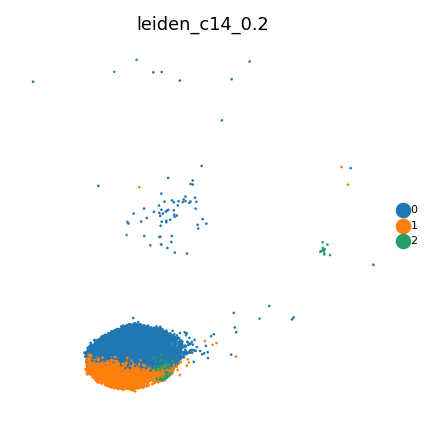

In [46]:
adata_14 = adata[adata.obs[cluster_key] == "14"].copy()
sc.tl.leiden(adata_14, n_iterations=-1, flavor = 'igraph', key_added = 'leiden_c14_0.2', random_state= 1000, resolution = 0.2)
sc.pl.umap(adata_14, color = 'leiden_c14_0.2', legend_fontsize= 5)

In [48]:
## Differential expressed genes

cluster_key = 'leiden_c14_0.2'
sample_key = 'ic_id_platform_adjusted_sample'
design= '~ ic_id_platform_adjusted_sample + leiden_c14_0.2'

# prc of expressed genes
pct_genes_df = dg.compute_pct_expressing(ad = adata_14, cluster_key = cluster_key, layer="counts", workers=60)
dds = dg.prepare_pseudobulk_deseq_analysis(ad = adata_14, 
                                           n_cells = 25,
                                           sample_key = sample_key, 
                                           cluster_key = cluster_key, 
                                           design = design, 
                                           layer='counts', 
                                           func='sum', 
                                           workers=60)
comparisons = [("1", "0")]

# Wald test
results_list = [
    dg.diff_genes_two_clusters(dds_obj = dds, cluster_index=cluster_key,
                            cluster_1=c1, cluster_2=c2, workers=60).assign(comparison=f"{c1}_vs_{c2}")
    for c1, c2 in comparisons
]

all_results = dg.extract_results(comparisons = comparisons, results_list = results_list, pct_genes_df=pct_genes_df)

all_results.to_csv(os.path.join(files_dir, "deg_wald_14_subcluster_0_vs_1.csv"), index_label= "gene_symbol")

Fitting size factors...


Using None as control genes, passed at DeseqDataSet initialization


... done in 0.33 seconds.

Fitting dispersions...
... done in 6.56 seconds.

Fitting dispersion trend curve...
/work/islet_cartography_scrna/scrna_cartography_py_analysis/lib/python3.13/site-packages/pydeseq2/dds.py:820: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.58 seconds.

Fitting MAP dispersions...
... done in 9.28 seconds.

Fitting LFCs...
... done in 16.65 seconds.

Calculating cook's distance...
... done in 0.53 seconds.

Replacing 0 outlier genes.



### Plot and save acinar marker expression

In [49]:
acinar_markers = {
    "Acinar_i": [
        "RBPJL", "CHRM3", "LRIG1", "INSR",
        "FOXP2", "CHN2", "DTNA", "SDK1",
        "MAP3K5", "CAMK1D"
    ],

    "Acinar_REG+": [
        "REG3A", "REG3G", "REG1B", "REG1A"],

    "Acinar_s": [
        "CPB1", "CPA1", "PRSS3", "PRSS1",
        "AMY2A", "CELA2A", "CELA3A", "CELA3B",
        "CELA3A", "CELA3B", "CTRB1", "CTRB2",
        "CLPS", "PNLIP", "SPINK1", "CTRC",
        "CPA2", "ANXA4"
    ]
}

In [52]:
sc.pl.stacked_violin(
    adata_14, 
    var_names=acinar_markers,
    groupby="leiden_c14_0.2", 
    swap_axes=True, 
    figsize=(3,6),
    show=False  
)

# Save the figure
plt.savefig(os.path.join(plot_dir, "cluster14_acinar_gene_expression_violin.pdf"), dpi=300, bbox_inches='tight')  # specify filename and format
plt.close()  # close the figure to free memory

In [54]:
sc.pl.matrixplot(adata_14, 
                 acinar_markers, 
                 groupby="leiden_c14_0.2", 
                 cmap="viridis",  
                 standard_scale='var', 
                 swap_axes= True, 
                 figsize=(3,6),
                 show = False,
                colorbar_title = 'Mean expression\nin group\n (min-max scaled)')

# Save the figure
plt.savefig(os.path.join(plot_dir, "cluster14_acinar_gene_expression_matrix.pdf"), dpi=300, bbox_inches='tight')  # specify filename and format
plt.close()  # close the figure to free memory

In [57]:
# add annotation to original data
adata.obs['leiden_1.5_subcluster'] = adata.obs['leiden_1.5_subcluster'].astype(str)
adata.obs.loc[adata_14.obs_names, 'leiden_1.5_subcluster'] = (
    '14_' + adata_14.obs['leiden_c14_0.2'].astype(str)
)

## Subclustering cluster 17

In [69]:
adata.obs['test'] = adata.obs['leiden_1.5_subcluster'].astype(str)
adata.obs.loc[adata_17.obs_names, 'test'] = (
    '17_' + adata_17.obs['leiden_c17_0.2'].astype(str)
)

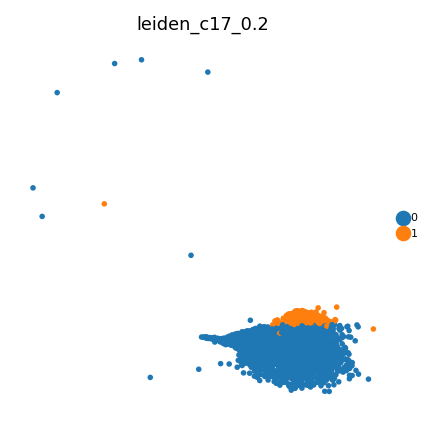

In [89]:
adata_17 = adata[adata.obs['leiden_1.5'] == "17"].copy()
sc.tl.leiden(adata_17, n_iterations=-1, flavor = 'igraph', key_added = 'leiden_c17_0.2', random_state= 1000, resolution = 0.1)
sc.pl.umap(adata_17, color = 'leiden_c17_0.2', legend_fontsize= 5)

In [74]:
## Differential expressed genes
cluster_key = 'leiden_c17_0.2'
sample_key = 'ic_id_platform_adjusted_sample'
design= '~ ic_id_platform_adjusted_sample + leiden_c17_0.2'

# prc of expressed genes
pct_genes_df = dg.compute_pct_expressing(ad = adata_17, cluster_key = cluster_key, layer="counts", workers=60)
dds = dg.prepare_pseudobulk_deseq_analysis(ad = adata_17, 
                                           n_cells = 25,
                                           sample_key = sample_key, 
                                           cluster_key = cluster_key, 
                                           design = design, 
                                           layer='counts', 
                                           func='sum', 
                                           workers=60)
comparisons = [("1", "0")]

# Wald test
results_list = [
    dg.diff_genes_two_clusters(dds_obj = dds, cluster_index=cluster_key,
                            cluster_1=c1, cluster_2=c2, workers=60).assign(comparison=f"{c1}_vs_{c2}")
    for c1, c2 in comparisons
]

all_results = dg.extract_results(comparisons = comparisons, results_list = results_list, pct_genes_df=pct_genes_df)

all_results.to_csv(os.path.join(files_dir, "deg_wald_17_subcluster_0_vs_1.csv"), index_label= "gene_symbol")

Fitting size factors...
... done in 0.07 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 2.43 seconds.

Fitting dispersion trend curve...
/work/islet_cartography_scrna/scrna_cartography_py_analysis/lib/python3.13/site-packages/pydeseq2/dds.py:820: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.48 seconds.

/work/islet_cartography_scrna/scrna_cartography_py_analysis/lib/python3.13/site-packages/pydeseq2/dds.py:548: UserWarning: As the residual degrees of freedom is less than 3, the distribution of log dispersions is especially asymmetric and likely to be poorly estimated by the MAD.
  self.fit_dispersion_prior()
Fitting MAP dispersions...
... done in 3.13 seconds.

Fitting LFCs...
... done in 5.45 seconds.

Calculating cook's distance...
... done in 0.08 seconds.

Replacing 0 outlier genes.



There are no differentially expressed genes

## Diff genes ductal cells

In [87]:
# subset adata object
adata_ductal = adata[adata.obs['leiden_1.5'].isin(["17", "18"])].copy()

## Differential expressed genes
cluster_key = 'leiden_1.5'
sample_key = 'ic_id_platform_adjusted_sample'
design= '~ ic_id_platform_adjusted_sample + leiden_1.5'

# prc of expressed genes
pct_genes_df = dg.compute_pct_expressing(ad = adata_ductal, cluster_key = cluster_key, layer="counts", workers=60)
dds = dg.prepare_pseudobulk_deseq_analysis(ad = adata_ductal, 
                                           n_cells = 25,
                                           sample_key = sample_key, 
                                           cluster_key = cluster_key, 
                                           design = design, 
                                           layer='counts', 
                                           func='sum', 
                                           workers=60)
comparisons = [("17", "18")]

# Wald test
results_list = [
    dg.diff_genes_two_clusters(dds_obj = dds, cluster_index=cluster_key,
                            cluster_1=c1, cluster_2=c2, workers=60).assign(comparison=f"{c1}_vs_{c2}")
    for c1, c2 in comparisons
]

all_results = dg.extract_results(comparisons = comparisons, results_list = results_list, pct_genes_df=pct_genes_df)

all_results.to_csv(os.path.join(files_dir, "deg_wald_17_vs_18.csv"), index_label= "gene_symbol")

Fitting size factors...


Using None as control genes, passed at DeseqDataSet initialization


... done in 0.36 seconds.

Fitting dispersions...
... done in 10.09 seconds.

Fitting dispersion trend curve...
/work/islet_cartography_scrna/scrna_cartography_py_analysis/lib/python3.13/site-packages/pydeseq2/dds.py:820: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.68 seconds.

Fitting MAP dispersions...
... done in 18.24 seconds.

Fitting LFCs...
... done in 31.10 seconds.

Calculating cook's distance...
... done in 0.67 seconds.

Replacing 0 outlier genes.



## Add annotation

In [93]:
cluster2annotation = {
    "0": "alpha",
    "1": "gamma",
    "2": "alpha",
    "3": "alpha",
    "4": "alpha",
    "5": "alpha",
    "6": "alpha",
    "7": "alpha",
    "8": "delta",
    "9": "beta",
    "10": "beta",
    "11": "beta",
    "12": "cycling",
    "13": "beta",
    "14_0": "acinar",
    "14_1": "acinar_reg_plus",
    "14_2": "acinar",
    "15": "antigen_presenting",
    "16": "schwann",
    "17": "ductal_muc",
    "18": "ductal",
    "19": "epsilon",
    "20": "quiescent_stellate",
    "21": "activated_stellate",
    "22_0": "endmt_early",
    "22_1": "endmt_late",
    "23": "islet_endothelial",
    "24": "mast"
}

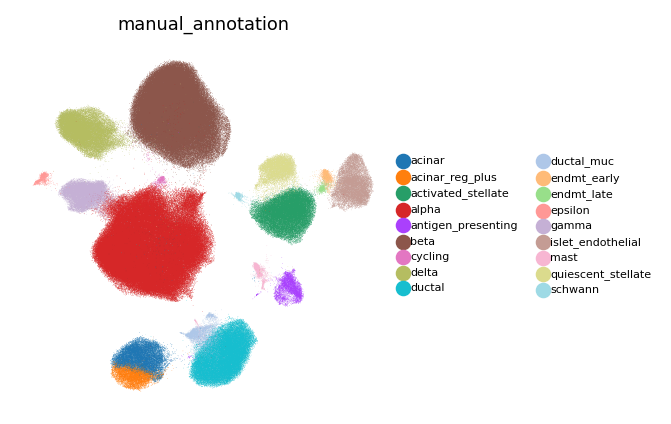

In [95]:
adata.obs["manual_annotation"] = adata.obs["leiden_1.5_subcluster"].map(cluster2annotation).astype("category")
sc.pl.umap(adata, color = 'manual_annotation', legend_fontsize= 5)

In [96]:
mi.set_my_theme()
with PdfPages(os.path.join(plot_dir, 'manual_annotation_umap.pdf')) as pdf:
    # UMAP
    fig, colors = ma.umap_single(
        ad=adata,
        legend_on_data=True,
        add_legend=False,
        variable='manual_annotation',
        pt_size=1
    )
    fig_obj = fig.figure if hasattr(fig, "figure") else fig
    fig_obj.tight_layout()
    pdf.savefig(fig_obj, bbox_inches='tight')
plt.close('all')

## Save AData object

In [98]:
adata.write_h5ad(os.path.join(anndata_dir, "AG_combined.h5ad"))

# Diffentiel expressed genes

### Set up 

In [ ]:
cluster_key = 'leiden_1.5'
sample_key = 'ic_id_platform_adjusted_sample'
design= '~ ic_id_platform_adjusted_sample + leiden_1.5'

### Percentage of cells expressing genes

In [ ]:
pct_genes_df = dg.compute_pct_expressing(ad = adata, cluster_key = cluster_key, layer="counts", workers=60)

### Prepare DDS object

In [ ]:
dds = dg.prepare_pseudobulk_deseq_analysis(ad = adata, 
                                           n_cells = 25,
                                           sample_key = sample_key, 
                                           cluster_key = cluster_key, 
                                           design = design, 
                                           layer='counts', 
                                           func='sum', 
                                           workers=60)

### Find differential genes between two clusters

In [ ]:
# Define comparisons
comparisons = [("22", "23"),
               ("22", "21"),
               ("22", "20"),
               ("16", "21"),
               ("16", "20"),
               ("20", "21"),
               ("17", "18")]

# Wald test
results_list = [
    dg.diff_genes_two_clusters(dds_obj = dds, cluster_index=cluster_key,
                            cluster_1=c1, cluster_2=c2, workers=60).assign(comparison=f"{c1}_vs_{c2}")
    for c1, c2 in comparisons
]

### Extract and set up results

In [ ]:
# Merge all results
all_results = pd.concat(results_list, ignore_index=False)

# Merge percentage of genes expressed
all_results = all_results.merge(pct_genes_df, left_index=True, right_index=True, how="left")

# Convert comparisons to categorical (optional, for sorting later)
comparison_order = [f"{c1}_vs_{c2}" for c1, c2 in comparisons]
all_results['comparison'] = pd.Categorical(all_results['comparison'], categories=comparison_order, ordered=True)

# Extract c1 from the comparison string
all_results['c1'] = all_results['comparison'].str.split('_vs_').str[0]

# Add helper column for percent expressed in c1
all_results['pct_expr_c1'] = all_results.apply(
    lambda row: row[f"pct_expr_cluster_{row['c1']}"], axis=1
)

# Reorder columns
cols_to_move = ['comparison', 'pct_expr_c1', ]
other_cols = [c for c in all_results.columns if c not in cols_to_move]
all_results = all_results[cols_to_move + other_cols]

In [253]:
all_results_flt = all_results.query('padj <= 0.05 and log2FoldChange >= 1')

### Save results

In [ ]:
all_results.to_csv(os.path.join(files_dir, "deg_wald_all_22_23_21_20_16_17_18.csv"), index_label= "gene_symbol")
all_results_flt.to_csv(os.path.join(files_dir, "deg_wald_sig_22_23_21_20_16_17_18.csv"), index_label= "gene_symbol")

### Plotting some results

In [280]:
all_results = pd.read_csv(os.path.join(files_dir, "deg_wald_all_22_23_21_20_16_17_18.csv"), index_col= 0)

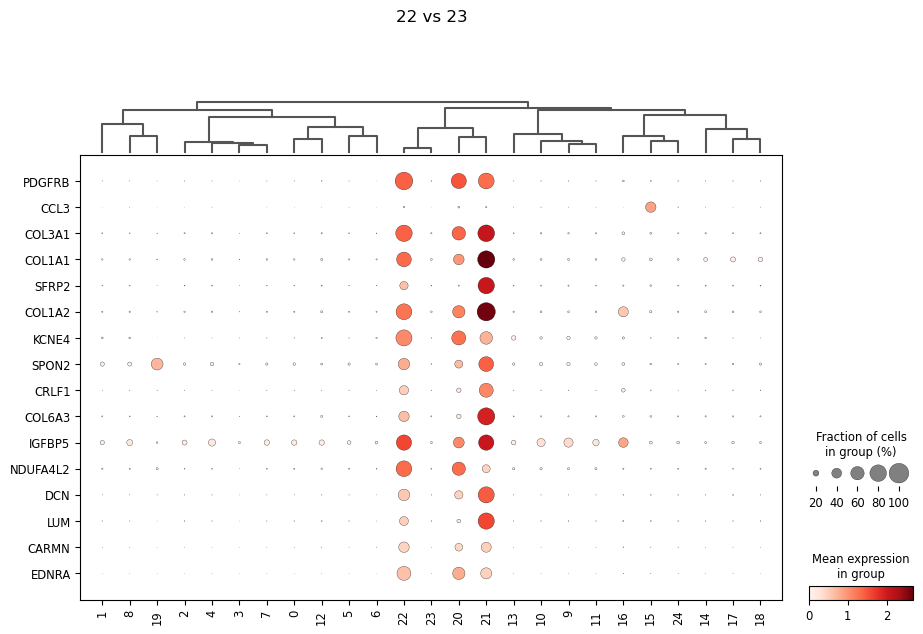

['PDGFRB', 'CCL3', 'COL3A1', 'COL1A1', 'SFRP2', 'COL1A2', 'KCNE4', 'SPON2', 'CRLF1', 'COL6A3', 'IGFBP5', 'NDUFA4L2', 'DCN', 'LUM', 'CARMN', 'EDNRA']


In [282]:
# Assuming c1 = 22 and c2 = 23 in the comparison
threshold_flt = all_results.query('padj <= 0.05 and log2FoldChange >= 6')

top23_markers = (
    threshold_flt
    # Filter for the specific comparison where C22 is the numerator
    .query("comparison == '22_vs_23'") 
    # Use nsmallest to find the largest negative log2FoldChange values
    .nlargest(20, ['log2FoldChange']) 
)

# Use the index (gene names) to plot
sc.pl.dotplot(adata, top23_markers.index.tolist(), groupby = 'leiden_1.5', dendrogram= True, swap_axes=True, title= "22 vs 23")

# Print the gene list for analysis
print(top23_markers.index.tolist())

In [161]:
pericyte_genes = {
    "Pericyte_Markers": [
        "CD248",  # Endosialin
        "ACTA2",  # Smooth Muscle Actin α2
        "ENG",    # Endoglin
        "VIM",    # Vimentin
        "POSTN"   # Periostin (low in naïve pericytes)
    ],
    "Fibrillar_Collagens": [
        "COL1A1", "COL1A2",  # Collagen I
        "COL3A1",            # Collagen III
        "COL5A1", "COL5A2", "COL5A3",  # Collagen V
        "COL6A1", "COL6A2", "COL6A3"   # Collagen VI
    ],
    "ECM_Proteins": [
        "FN1",   # Fibronectin
        "ELN",   # Elastin
        "TNXB"   # Tenascin-X
    ],
    "Proteoglycans": [
        "DCN",   # Decorin
        "BGN",   # Biglycan
        "LUM",   # Lumican
        "OGN",   # Osteoglycin
        "PODN",  # Podocan
        "HAS1"   # Hyaluronan synthase 1
    ],
    "Basement_Membrane_Components": [
        "COL4A1", "COL4A2",  # Collagen IV
        "COL15A1",            # Collagen XV
        "HSPG2",              # Perlecan
        "NID1", "NID2",       # Nidogen 1 and 2
        "LAMA2", "LAMA4",     # Laminin α2, α4
        "LAMB1", "LAMB2",     # Laminin β1, β2
        "LAMC1"               # Laminin γ1
    ]
}


### Cluster 22 vs other

In [64]:
adata_subset = adata.copy()
adata_subset.obs['22_vs_other'] = adata_subset.obs['leiden_1.5'].apply(lambda x: '22' if x == '22' else 'other')

In [65]:

adata_subset = adata.copy()
adata_subset.obs['22_vs_other'] = adata_subset.obs['leiden_1.5'].apply(lambda x: '22' if x == '22' else 'other')
cluster_key = '22_vs_other'
sample_key = 'ic_id_platform_adjusted_sample'
design= '~ ic_id_platform_adjusted_sample + 22_vs_other'

pct_genes_df = dg.compute_pct_expressing(ad = adata_subset, cluster_key = 'leiden_1.5', layer="counts", workers=60)

dds = dg.prepare_pseudobulk_deseq_analysis(ad = adata_subset, 
                                           n_cells = 25,
                                           sample_key = sample_key, 
                                           cluster_key = cluster_key, 
                                           design = design, 
                                           layer='counts', 
                                           func='sum', 
                                           workers=60)

# Define comparisons
comparisons = [("22", "other")]

# Wald test
results_list = [
    dg.diff_genes_two_clusters(dds_obj = dds, cluster_index=cluster_key,
                            cluster_1=c1, cluster_2=c2, workers=60).assign(comparison=f"{c1}_vs_{c2}")
    for c1, c2 in comparisons
]

all_results = dg.extract_results(comparisons = comparisons, results_list = results_list, pct_genes_df=pct_genes_df)

Fitting size factors...


Using None as control genes, passed at DeseqDataSet initialization


... done in 0.52 seconds.

Fitting dispersions...
... done in 40.40 seconds.

Fitting dispersion trend curve...
/work/islet_cartography_scrna/scrna_cartography_py_analysis/lib/python3.13/site-packages/pydeseq2/dds.py:820: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.96 seconds.

Fitting MAP dispersions...
... done in 132.37 seconds.

Fitting LFCs...
... done in 134.12 seconds.

Calculating cook's distance...
... done in 1.20 seconds.

Replacing 0 outlier genes.



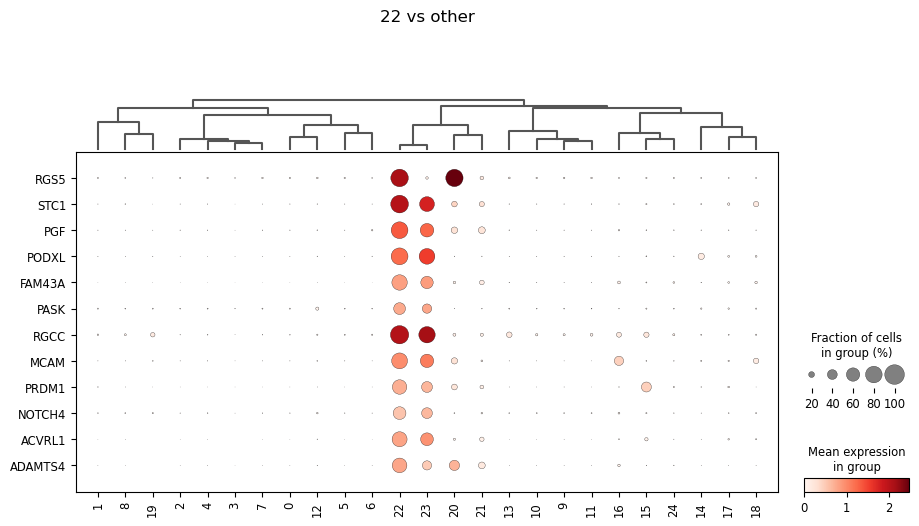

In [274]:
all_results = dg.extract_results(comparisons = comparisons, results_list = results_list, pct_genes_df=pct_genes_df)
all_results_flt = all_results.query('padj <= 0.05 and log2FoldChange >= 5.5')

top10 = (
    all_results_flt
    .query("comparison == '22_vs_other' and pct_expr_c1 >= 5")
    .nlargest(50, ['log2FoldChange'])
)

sc.tl.dendrogram(adata, groupby="leiden_1.5", use_rep='X_latent_1')
sc.pl.dotplot(adata, top10.index.tolist(), groupby = 'leiden_1.5', dendrogram= True, swap_axes=True, title = "22 vs other")

### Save results

In [131]:
all_results.to_csv(os.path.join(files_dir, "deg_wald_all_22_vs_other.csv"), index_label= "gene_symbol")
all_results_flt.to_csv(os.path.join(files_dir, "deg_wald_sig_22_vs_other.csv"), index_label= "gene_symbol")

## Module score of subtypes of hepatic stellate cells from [Merens, Vincent et al.](https://doi.org/10.1016/j.jhepr.2024.101223)

(Access: 08-12-2025)

In [133]:
genes_hsc = pd.read_csv(os.path.join(files_dir, "mmc5_SF2_HSC_subtype_genesets.csv"))

### Convert mouse gene symbols to human and create dictionary

In [134]:
# mouse to human symbol
genes_hsc = mi.mouse_2_human(genes_hsc, mouse_col = "Gene")

# dictionary
gene_hsc_list = {}

df_grouped = genes_hsc.groupby('HSC stage')['human_symbol'].apply(list)
for celltype, genes in df_grouped.items(): 
    key = f"{celltype}"
    gene_hsc_list[key] = genes

### UCell score

In [10]:
uc.compute_ucell_scores(adata, signatures=gene_hsc_list, n_jobs= 60)
adata.obs[adata.obs.columns[adata.obs.columns.str.endswith('UCell')]].to_csv(os.path.join(files_dir, "hcs_marker_gene_scores.csv"), index_label='barcode')

In [144]:
ucell_score = pd.read_csv(os.path.join(files_dir, "hcs_marker_gene_scores.csv"), index_col=0)

In [145]:
adata.obs = adata.obs.join(ucell_score)

categories: 20, 21, 22, etc.
var_group_labels: initiatory, myofibroblasts, quiescent


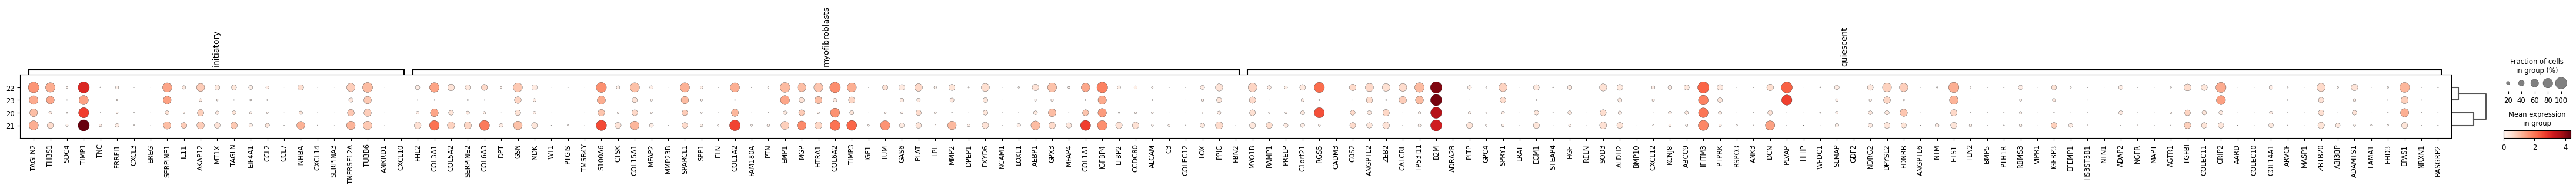

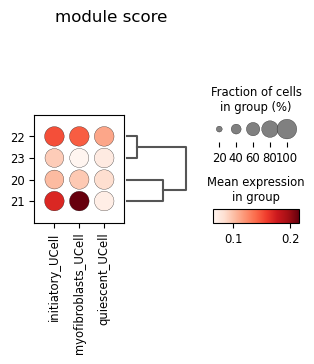

In [147]:
adata_sub = adata[adata.obs['leiden_1.5'].isin(['20', '21', '22', '23'])].copy()
sc.tl.dendrogram(adata_sub, groupby="leiden_1.5", use_rep='X_latent_1')
sc.pl.dotplot(adata_sub, gene_hsc_list, groupby = 'leiden_1.5', dendrogram= True)
sc.pl.dotplot(adata_sub, ucell_score.columns.tolist(), groupby = 'leiden_1.5', dendrogram= True, title = "module score")

categories: 0, 1, 2, etc.
var_group_labels: alpha, beta, delta, etc.


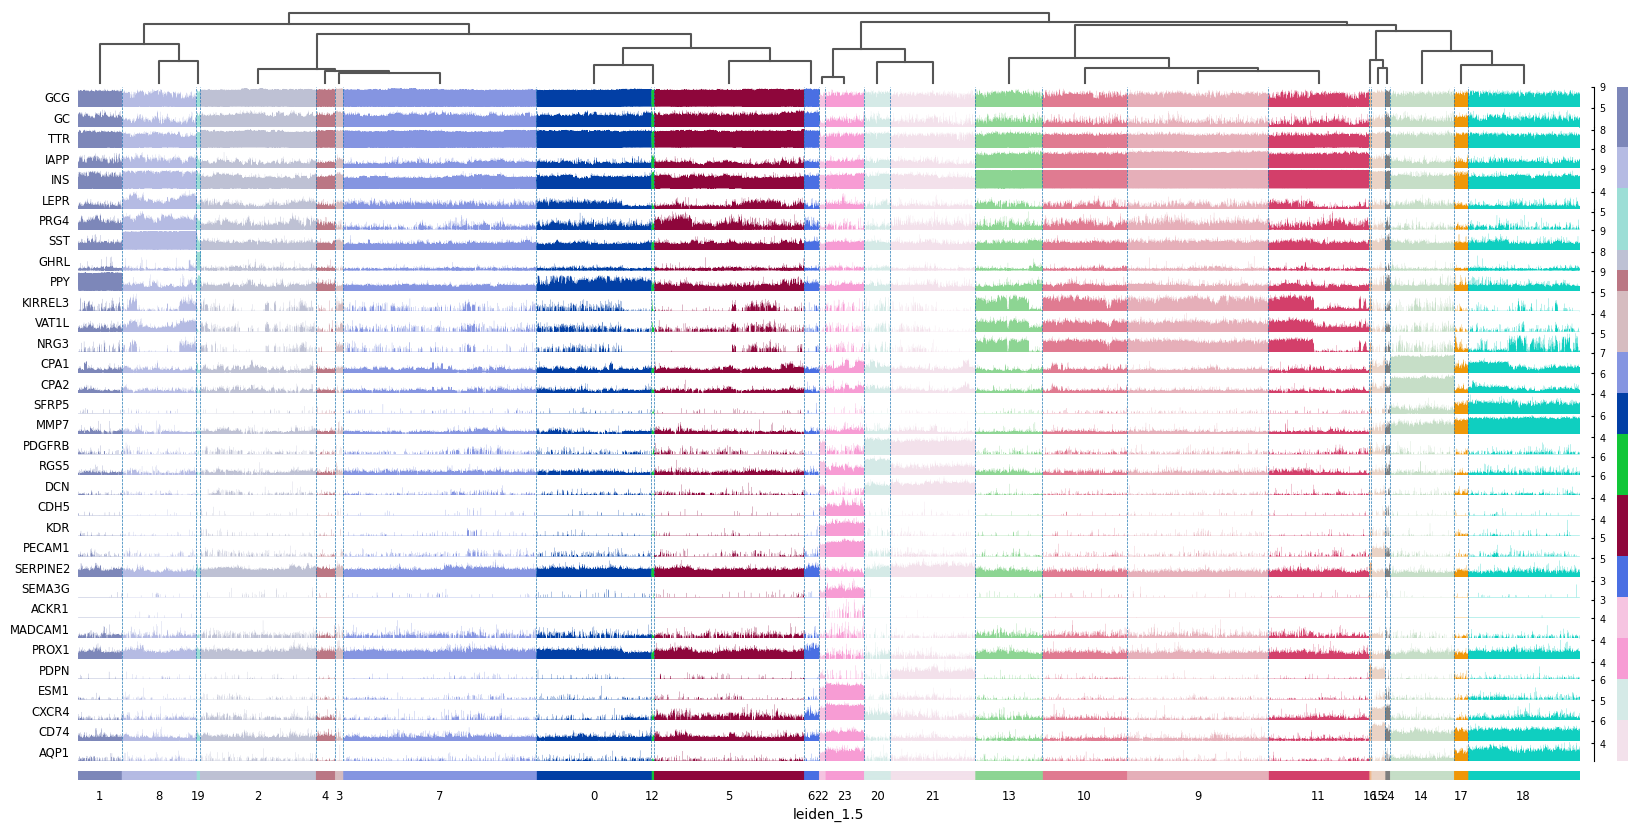

In [159]:
marker_genes = {
    "alpha": ["GCG", "GC","TTR"],
    "beta": ["IAPP", "INS"],
    "delta": ["LEPR", "PRG4", "SST"],
    "epsilon": ["GHRL"],
    "pp_gamma": ["PPY"],
    "ganglial": ["KIRREL3", "VAT1L", "NRG3"],
    "acinar": ["CPA1", "CPA2"],
    "ductal": ["SFRP5", "MMP7"],
    "stromal": ["PDGFRB", "RGS5", "DCN"],
    "endothelial_general": ["CDH5", "KDR", "PECAM1"],
    "endothelial_arterial": ["SERPINE2", "SEMA3G"],
    "endothelial_venous": ["ACKR1", "MADCAM1"],
    "endothelial_lymphatic": ["PROX1", "PDPN"],
    "endothelial_islet": ["ESM1", "CXCR4"],
    "endothelial_acinar": ["CD74", "AQP1"]
}

sc.pl.tracksplot(adata, marker_genes, groupby="leiden_1.5", dendrogram=True, figsize = (20, 10))

categories: 20, 21, 22, etc.
var_group_labels: initiatory, myofibroblasts, quiescent


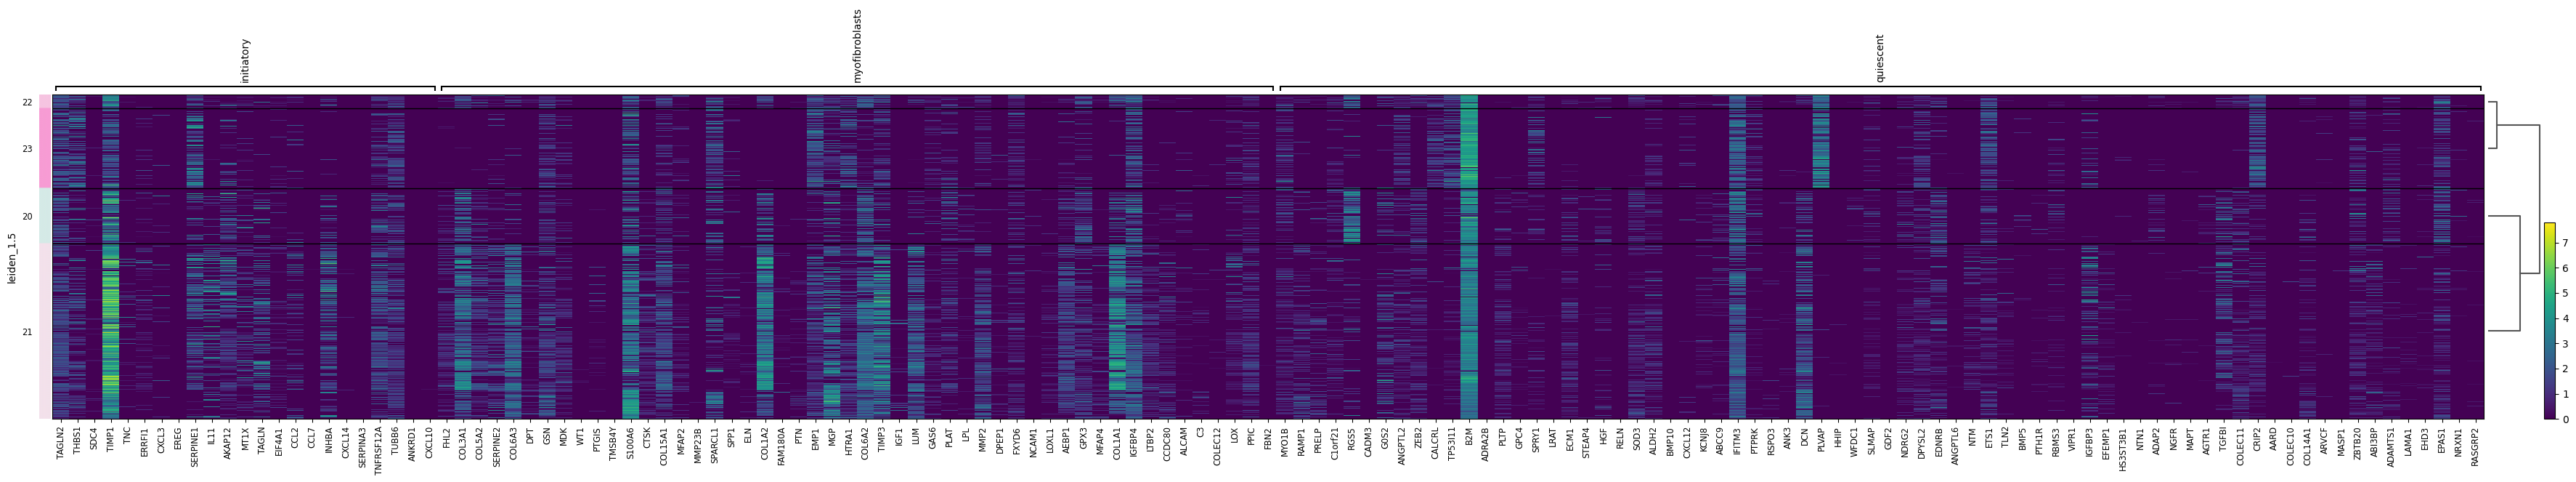

In [185]:
#sc.pl.dotplot(adata_sub, pericyte_genes, groupby = 'leiden_1.5', dendrogram= True, swap_axes=True)
sc.pl.heatmap(adata_sub, gene_hsc_list, groupby="leiden_1.5", cmap="viridis", dendrogram=True, show_gene_labels=True)

In [179]:
print(adata.obs[adata.obs['leiden_1.5'].isin(['22'])]['final_level_labels'].value_counts())

final_level_labels
Endothelial cell                         1796
Fibroblast                                166
Pericyte                                  141
Capillary EC                               36
Endothelial‑mesenchymal transition EC      16
                                         ... 
abT (entry) cell                            0
cDC                                         0
cDC2                                        0
cholangiocyte                               0
mregDC                                      0
Name: count, Length: 213, dtype: int64


## Annotate cells

### Create dictionary to map cluster to annotation label

In [5]:
cluster2annotation = {
    "0": "alpha",
    "1": "gamma",
    "2": "alpha",
    "3": "alpha",
    "4": "alpha",
    "5": "alpha",
    "6": "alpha",
    "7": "alpha",
    "8": "delta",
    "9": "beta",
    "10": "beta",
    "11": "beta",
    "12": "cycling",
    "13": "beta",
    "14": "acinar",
    "15": "antigen_presenting",
    "16": "schwann",
    "17": "ductal_muc",
    "18": "ductal",
    "19": "epsilon",
    "20": "quiescent_stellate",
    "21": "activated_stellate",
    "22": "not_clear",
    "23": "islet_endothelial",
    "24": "mast"
}

### Add annotation

In [6]:
adata.obs["manual_annotation"] = adata.obs["leiden_1.5"].map(cluster2annotation).astype("category")

### UMAP

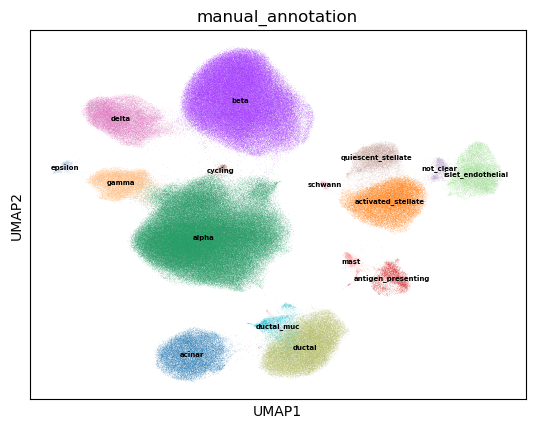

In [7]:
sc.pl.umap(adata, color = "manual_annotation", legend_loc= "on data", legend_fontsize= 5)

## Differential expressed genes between one cluster and all the rest

In [12]:
sample_key = 'ic_id_platform_adjusted_sample'
cluster_key = 'manual_annotation' 
layer = 'counts'
workers = 60

# Compute percent expressing genes once using the cluster_key
pct_genes_df = dg.compute_pct_expressing(
    ad=adata, 
    cluster_key=cluster_key, 
    layer=layer, 
    workers=workers
)

all_results_list = []

# Loop over each unique cluster in manual_annotation
for cluster_id in adata.obs[cluster_key].unique():

    # Create binary column for current cluster vs others
    col_name = f"{cluster_id}_vs_other"
    adata.obs[col_name] = adata.obs[cluster_key].apply(lambda x: cluster_id if x == cluster_id else 'other')

    # Prepare pseudobulk DESeq object
    dds = dg.prepare_pseudobulk_deseq_analysis(
        ad=adata,
        n_cells=25,
        sample_key=sample_key,
        cluster_key=col_name,
        design=f'~ {sample_key} + {col_name}',
        layer=layer,
        func='sum',
        workers=workers
    )

    # Define comparison
    comparisons = [(cluster_id, 'other')]

    # Run Wald test
    results_list = [
        dg.diff_genes_two_clusters(
            dds_obj=dds,
            cluster_index=col_name,
            cluster_1=c1,
            cluster_2=c2,
            workers=workers
        ).assign(comparison=f"{cluster_id}_vs_other")
        for c1, c2 in comparisons
    ]

    # Extract results
    all_results = dg.extract_results(
        comparisons=comparisons, 
        results_list=results_list, 
        pct_genes_df=pct_genes_df
    )

    # Save results
    all_results.to_csv(os.path.join(files_dir, f"deg_wald_manual_annotation_{cluster_id}_vs_all.csv"), index_label= "gene_symbol")

    # Append to list
    all_results_list.append(all_results)

# Concatenate all results into a single dataframe
final_results_df = pd.concat(all_results_list, axis=0).reset_index(drop=True)

# save
final_results_df.to_csv(os.path.join(files_dir, "deg_wald_manual_annotation.csv"), index_label= "gene_symbol")

Fitting size factors...


Using None as control genes, passed at DeseqDataSet initialization


... done in 0.85 seconds.

Fitting dispersions...
... done in 143.88 seconds.

Fitting dispersion trend curve...
/work/islet_cartography_scrna/scrna_cartography_py_analysis/lib/python3.13/site-packages/pydeseq2/dds.py:820: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.84 seconds.

Fitting MAP dispersions...
... done in 102.37 seconds.

Fitting LFCs...
... done in 182.26 seconds.

Calculating cook's distance...
... done in 1.77 seconds.

Replacing 0 outlier genes.

Fitting size factors...


Using None as control genes, passed at DeseqDataSet initialization


... done in 0.65 seconds.

Fitting dispersions...
... done in 160.24 seconds.

Fitting dispersion trend curve...
/work/islet_cartography_scrna/scrna_cartography_py_analysis/lib/python3.13/site-packages/pydeseq2/dds.py:820: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.87 seconds.

Fitting MAP dispersions...
... done in 111.71 seconds.

Fitting LFCs...
... done in 186.12 seconds.

Calculating cook's distance...
... done in 1.63 seconds.

Replacing 0 outlier genes.

Fitting size factors...


...

Using None as control genes, passed at DeseqDataSet initialization


... done in 0.48 seconds.

Fitting dispersions...
... done in 33.17 seconds.

Fitting dispersion trend curve...
/work/islet_cartography_scrna/scrna_cartography_py_analysis/lib/python3.13/site-packages/pydeseq2/dds.py:820: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 1.03 seconds.

Fitting MAP dispersions...
... done in 130.09 seconds.

Fitting LFCs...
... done in 123.08 seconds.

Calculating cook's distance...
... done in 1.13 seconds.

Replacing 0 outlier genes.

Fitting size factors...


Using None as control genes, passed at DeseqDataSet initialization


... done in 0.47 seconds.



ValueError: The number of samples and the number of design variables are equal, i.e., there are no replicates to estimate the dispersion. Please use a design with fewer variables.